In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("logistic_regression_dataset.csv")

In [4]:
x = np.array([df["x1"],df["x2"]]).T
y = np.array(df["y"])

In [5]:
y = y.reshape(-1,1)

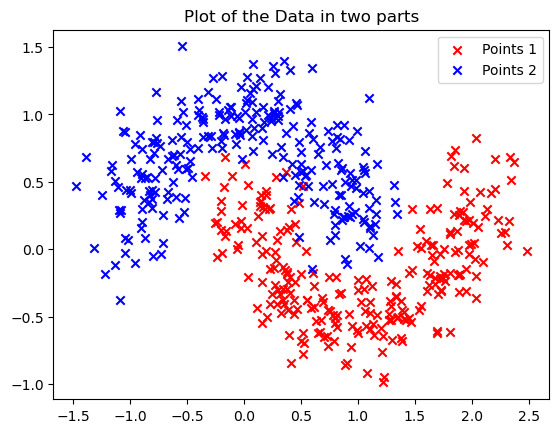

In [6]:
plt.scatter(df['x1'][df['y']==1],df['x2'][df['y']==1],c = 'red',marker='x',label = 'Points 1')
plt.scatter(df['x1'][df['y']==0],df['x2'][df['y']==0],c = 'blue',marker='x',label = 'Points 2')
plt.title("Plot of the Data in two parts")
plt.legend()
plt.show()

In [7]:
def sigmoid(z):
    z = np.clip(z,-500,500)
    return 1/(1+np.exp(-z))

In [8]:
def loss(x, y, lam, theta):
    m = len(y)
    hx = sigmoid(np.dot(x, theta))  # Compute predictions
    epsilon  = 1e-9

    hx = np.clip(hx,epsilon,1-epsilon)

    # Compute logistic regression loss
    loss_term = -(y * np.log(hx) + (1 - y) * np.log(1 - hx))

    # Compute regularization term (ignoring theta[0])
    reg_term = (lam / (2 * m)) * np.sum(theta[1:] ** 2)

    # Final loss: Mean loss + Regularization
    total_loss = np.sum(loss_term) / m + reg_term

    return total_loss  # Return a scalar


In [9]:
def grad_decent(x,y,lam,theta,alpha,iters):
    theta_tilda = theta.copy()
    theta_tilda[0] = 0
    m = len(y)
    cost = []

    for i in range(iters):
        hx = sigmoid(np.dot(x,theta))
        error = hx - y
        grad = (np.dot(x.T,error) + lam*theta_tilda)/m

        theta -= alpha*grad
        cost.append(loss(x,y,lam,theta))

    return theta,cost


In [10]:
def expand_feature(x1,x2,power = 2):
    new_x = np.ones((x1.shape[0],1))  #1 column (bias term)
    for i in range(1,power+1):
        for j in range(i+1):
            new_x = np.append(new_x,(x1**(i-j)*(x2**j)).reshape(-1,1),axis = 1)
            # this reshape is very important as it changes the 1D vector to column vectoe
    return new_x

In [11]:
def predict(theta,x):
    return (sigmoid(np.dot(x,theta))>0.5).flatten()

In [12]:
def logistic_regression(x,y,lam = 1,power = 2,alpha = 0.01,iters = 100 ):
    x = expand_feature(x[:,0],x[:,1],power=power)
    print(x.shape)
    theta = np.zeros((x.shape[1],1),dtype=np.float64)
    theta,costs = grad_decent(x,y,lam,theta,alpha,iters)
    predicted = predict(theta,x)
    return predicted,theta,costs

In [13]:
power , num = 8,20000
predicted,theta,costs = logistic_regression(x,y,lam=0,power=power,alpha=0.6,iters=num)

(500, 45)


In [14]:
print('The accuracy is {:.2f}%'.format(sum(predicted==y.flatten())/len(y)*100))

The accuracy is 98.40%


In [15]:
theta.shape

(45, 1)

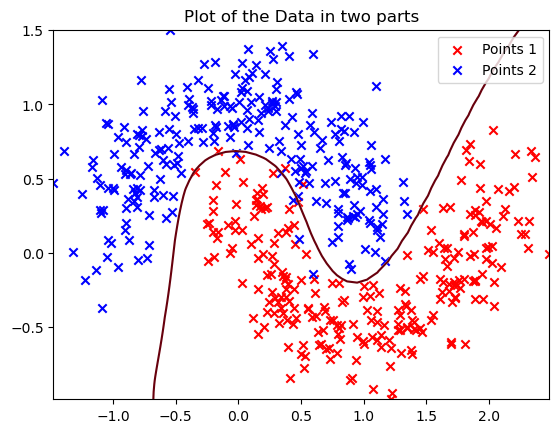

In [16]:
u = np.linspace(min(x[:,0]),max(x[:,0]),50)
v = np.linspace(min(x[:,1]),max(x[:,1]),50)

z = np.zeros((len(u),len(v)))

for i in range(len(u)):
    for j in range(len(v)):
        z[i,j] = np.dot(expand_feature(u[i].reshape(-1,1),v[j].reshape(-1,1),power=power),theta).item()
z = np.transpose(z)
plt.contour(u,v,z,[0,0.01],cmap = 'Reds')
plt.scatter(df['x1'][df['y']==1],df['x2'][df['y']==1],c = 'red',marker='x',label = 'Points 1')
plt.scatter(df['x1'][df['y']==0],df['x2'][df['y']==0],c = 'blue',marker='x',label = 'Points 2')
plt.title("Plot of the Data in two parts")
plt.legend()
plt.show()